In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
df = pd.read_excel(
    '../Dataset/loan_approval_data.xlsx',
    engine='openpyxl'
)

In [6]:
gen=df['Gender'].mode()[0]

df['Gender'].fillna(value=gen, inplace=True)


mar=df['Married'].mode()[0]
mar
df['Married'].fillna(value=mar, inplace=True)



dep=df['Dependency'].mode()[0]
dep
df['Dependency'].fillna(value=dep, inplace=True)

edu=df['Education'].mode()[0]
edu
df['Education'].fillna(value=edu, inplace=True)



emp=df['Self_Employed'].mode()[0]
emp
df['Self_Employed'].fillna(value=emp, inplace=True)

num_cols = [
    'ApplicantIncome',
    'LoanAmount'
]

for col in num_cols:
    df[col].fillna(df[col].median(), inplace=True)

C:\Users\user\AppData\Local\Temp\ipykernel_14804\585880595.py:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Gender'].fillna(value=gen, inplace=True)
C:\Users\user\AppData\Local\Temp\ipykernel_14804\585880595.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, wh

In [7]:
bin=[
    0,3126.000000,5055.000000,8736.250000
, float('inf')
]
label=[
    'Low', 'Medium','High','Very High'
]

df['Income_category']= pd.cut(df['ApplicantIncome'],
                              bins=bin,
                              labels=label)

df["Large_loan"]=np.where(
    df['LoanAmount']>170

    , 1,0
)



In [8]:
x= df.drop('Loan_Status', axis=1)

y = df['Loan_Status'].map({
    'Y':1,
    'N':0
})
from sklearn.model_selection import train_test_split


x_train, x_test, y_train, y_test = train_test_split(
    x,
    y,
    test_size=0.2,
    random_state=42,
    # stratify=y
)

In [9]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    StandardScaler,
    OneHotEncoder,
    OrdinalEncoder
)

In [10]:
num_features = [ 'ApplicantIncome', 'LoanAmount', 'Large_loan' ] 

num_transformer=StandardScaler() 
cat_transformer=OneHotEncoder( handle_unknown='ignore',
drop='first' ) 


ordinal_transformer = OrdinalEncoder( )

binary_features = [ 'Gender', 'Married', 'Education', 'Self_Employed', ] 

ordinal_features = [ 'Dependency', 'Income_category' ]

binary_features = [ 'Gender', 'Married', 'Education', 'Self_Employed', ] 

ordinal_features = [ 'Dependency', 'Income_category' ]

processor=ColumnTransformer(transformers=[
    ('num', num_transformer,num_features),
    ('cat',cat_transformer,binary_features),
    ('ord',ordinal_transformer, ordinal_features)


])

x_train_transformed=processor.fit_transform(x_train)
x_test_transformed=processor.transform(x_test)

df.drop('Loan_ID', axis=1, inplace=True)


processor.get_feature_names_out()

array(['num__ApplicantIncome', 'num__LoanAmount', 'num__Large_loan',
       'cat__Gender_Male', 'cat__Married_Yes',
       'cat__Education_Not Graduate', 'cat__Self_Employed_Yes',
       'ord__Dependency', 'ord__Income_category'], dtype=object)

In [11]:
import matplotlib.pyplot as plt

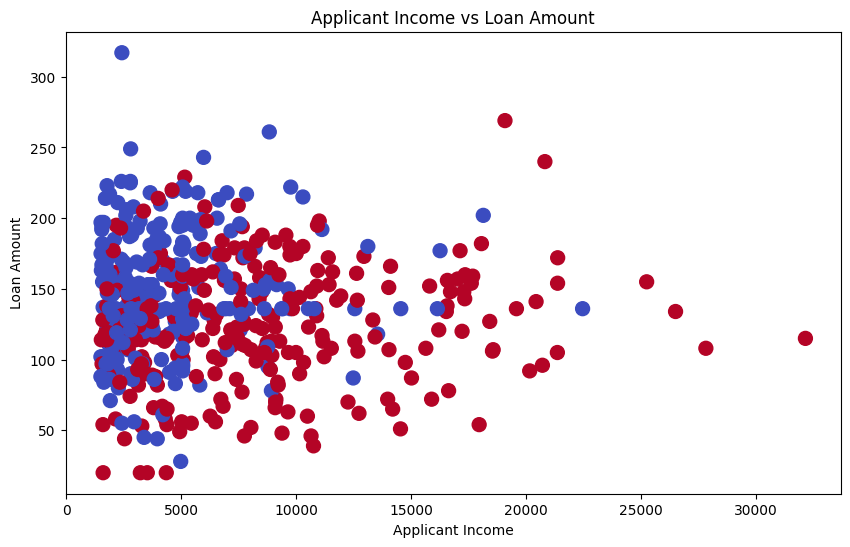

In [12]:
y = df['Loan_Status'].map({
    'Y': 1,
    'N': 0
})
plt.figure(figsize=(10,6))

plt.scatter(
    x['ApplicantIncome'],
    x['LoanAmount'],
    c=y,
    cmap='coolwarm',
    s=100
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")
plt.title("Applicant Income vs Loan Amount")

plt.show()

In [37]:
def perceptron(X,y):
    
    X = np.insert(X,0,1,axis=1)
    weights = np.ones(X.shape[1])
    lr = 0.1
    
    for i in range(1000):
        j = np.random.randint(0,x_train_transformed.shape[0])
        y_hat = step(np.dot(X[j],weights))
        weights = weights + lr*(y[j]-y_hat)*X[j]
        
    return weights[0],weights[1:]


def step(z):
    return 1 if z>0 else 0



X_vis = df[['ApplicantIncome', 'LoanAmount']].values

y_vis = df['Loan_Status'].map({
    'Y': 1,
    'N': 0
}).values


intercept_, coef_ = perceptron(X_vis, y_vis)

In [38]:
print(coef_)
print(intercept_)

[  449.9 -2103. ]
-10.09999999999998


In [39]:
m = -(coef_[0]/coef_[1])
b = -(intercept_/coef_[1])

In [40]:
m

np.float64(0.21393247741321966)

In [41]:
b

np.float64(-0.004802662862577262)

Text(0, 0.5, 'Loan Amount')

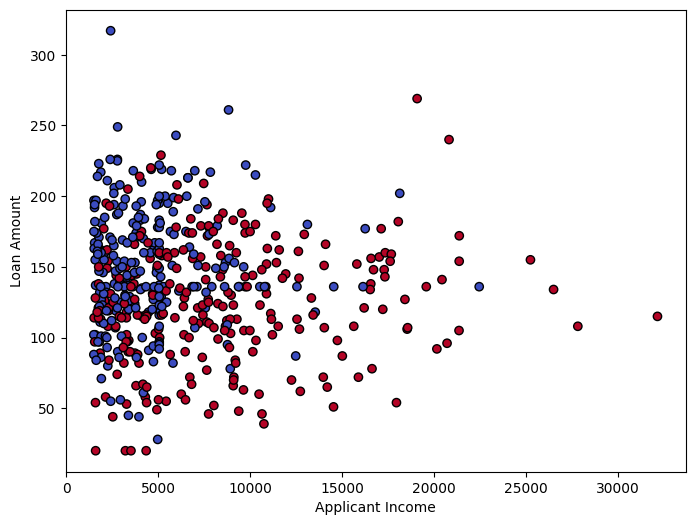

In [42]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

plt.scatter(
    X_vis[:,0],
    X_vis[:,1],
    c=y_vis,
    cmap='coolwarm',
    edgecolors='k'
)

plt.xlabel("Applicant Income")
plt.ylabel("Loan Amount")

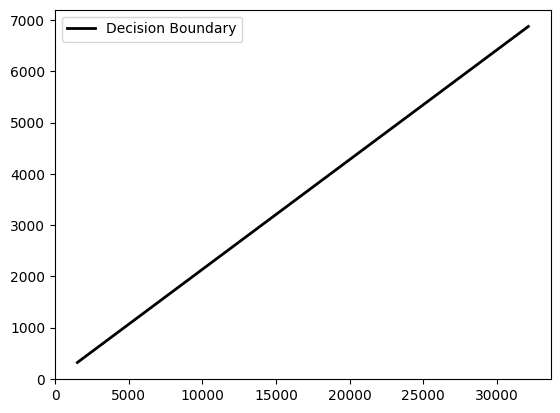

In [43]:
x1 = np.linspace(
    X_vis[:,0].min(),
    X_vis[:,0].max(),
    100
)

x2 = -(coef_[0] * x1 + intercept_) / coef_[1]

plt.plot(
    x1,
    x2,
    color='black',
    linewidth=2,
    label='Decision Boundary'
)

plt.legend()
plt.show()

In [44]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))